# 04c — 4채널 RNN / LSTM (Val HP 튜닝 + EarlyStopping)

- 입력: V, I (CSV) + TS, WFR (폴더명) → 4채널
- Train: Test1~43 (44,45 제외)
- Val:   Test44, Test45 → HP 튜닝 기준 + EarlyStopping (patience=20)
- Test:  Val1,2,5,8,9

In [24]:
from pathlib import Path
import torch

BASE_DIR  = Path.home() / 'Desktop' / 'ai1' / 'original_INC_202501'
MODEL_DIR = Path.home() / 'Desktop' / 'ai1' / 'rnn_lstm_4ch_model'
MODEL_DIR.mkdir(exist_ok=True)

FEATURES    = ['Avg Voltage', 'Avg Current']
WINDOW_SIZE = 30
STEP_SIZE   = 10
N_ITER      = 20       # HP 탐색 후보 수
MAX_EPOCHS  = 300
PATIENCE    = 20       # val EarlyStopping patience
RANDOM_SEED = 42

PARAM_DIST = {
    'hidden1':    [32, 64, 128],
    'hidden2':    [16, 32, 64],
    'dropout':    [0.2, 0.3, 0.5],
    'lr':         [1e-3, 5e-4],
    'batch_size': [16, 32],
}

NORMAL_TEST_IDS   = {1,2,3,4,5,7,8,9,10,11,12,28,29,30,44}
ABNORMAL_TEST_IDS = {6,31,45} | set(range(32,44))
NORMAL_VAL_IDS    = set(range(3,10))
ABNORMAL_VAL_IDS  = {1,2}
VAL_TRIAL_IDS     = {44,45}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [25]:
import re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score, f1_score
)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
crit = nn.BCELoss()
print('PyTorch:', torch.__version__, '| Device:', DEVICE)

PyTorch: 2.11.0+cu128 | Device: cuda


In [26]:
# 데이터 로드: V, I (trial z-score) + TS, WFR (폴더명)
def parse_folder_id(name):
    m = re.match(r'^(Test|Val)(\d+)_', name, flags=re.IGNORECASE)
    if not m: return None, None
    return m.group(1).capitalize(), int(m.group(2))

def parse_meta(name):
    m = re.search(r'_(\d+)TS_(\d+)WFR', name, re.IGNORECASE)
    if not m: return None, None
    return float(m.group(1)), float(m.group(2))

def get_label(prefix, idx):
    if prefix == 'Test':
        if idx in NORMAL_TEST_IDS:   return 0
        if idx in ABNORMAL_TEST_IDS: return 1
    elif prefix == 'Val':
        if idx in NORMAL_VAL_IDS:    return 0
        if idx in ABNORMAL_VAL_IDS:  return 1
    raise ValueError()

def get_split(prefix, idx):
    if prefix == 'Val':       return 'test'
    if idx in VAL_TRIAL_IDS:  return 'val'
    return 'train'

records = []
for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir(): continue
    prefix, idx = parse_folder_id(d.name)
    if prefix is None: continue
    try:
        label = get_label(prefix, idx)
        split = get_split(prefix, idx)
    except ValueError: continue
    ts, wfr = parse_meta(d.name)
    if ts is None: continue
    csvs = list(d.glob('*.csv'))
    if not csvs: continue
    raw = pd.read_csv(csvs[0])[FEATURES].astype(float).values
    mean, std = raw.mean(0), raw.std(0)
    std[std < 1e-8] = 1e-8
    vi = (raw - mean) / std
    ts_col  = np.full((len(vi), 1), ts)
    wfr_col = np.full((len(vi), 1), wfr)
    data = np.hstack([vi, ts_col, wfr_col])  # (N, 4)
    records.append({'label': label, 'split': split, 'data': data})

print(f'Trial 수: {len(records)}')

Trial 수: 19


In [27]:
# 윈도우 생성 + 글로벌 StandardScaler (train 기준 fit)
def make_windows(data, ws, ss):
    return np.stack([data[s:s+ws] for s in range(0, len(data)-ws+1, ss)])

buckets = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
for r in records:
    wins   = make_windows(r['data'], WINDOW_SIZE, STEP_SIZE)
    labels = np.full(len(wins), r['label'], dtype=np.float32)
    buckets[r['split']][0].append(wins)
    buckets[r['split']][1].append(labels)

X = {s: np.vstack(buckets[s][0]).astype(np.float32) for s in buckets}
y = {s: np.concatenate(buckets[s][1])               for s in buckets}

n_feat = X['train'].shape[2]  # 4
scaler = StandardScaler()
scaler.fit(X['train'].reshape(-1, n_feat))

def scale(arr):
    n, w, f = arr.shape
    return scaler.transform(arr.reshape(-1, f)).reshape(n, w, f).astype(np.float32)

Xs = {s: scale(X[s]) for s in X}

for s in ('train', 'val', 'test'):
    u, c = np.unique(y[s], return_counts=True)
    cnt  = dict(zip(u.astype(int), c))
    print(f'{s:5s}  {Xs[s].shape}  normal={cnt.get(0,0):4d}  abnormal={cnt.get(1,0):4d}')

train  (364, 30, 4)  normal= 183  abnormal= 181
val    (58, 30, 4)  normal=  29  abnormal=  29
test   (150, 30, 4)  normal=  95  abnormal=  55


In [28]:
# 모델 정의 + Dataset
class WindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class RNNModel(nn.Module):
    def __init__(self, n_feat, h1, h2, dropout):
        super().__init__()
        self.rnn1  = nn.RNN(n_feat, h1, batch_first=True, nonlinearity='tanh')
        self.drop1 = nn.Dropout(dropout)
        self.rnn2  = nn.RNN(h1, h2, batch_first=True, nonlinearity='tanh')
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Linear(h2, 1)

    def forward(self, x):
        out, _ = self.rnn1(x);  out = self.drop1(out)
        out, _ = self.rnn2(out)
        return torch.sigmoid(self.fc(self.drop2(out[:, -1, :]))).squeeze(-1)


class LSTMModel(nn.Module):
    def __init__(self, n_feat, h1, h2, dropout):
        super().__init__()
        self.lstm1 = nn.LSTM(n_feat, h1, batch_first=True)
        self.drop1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(h1, h2, batch_first=True)
        self.drop2 = nn.Dropout(dropout)
        self.fc    = nn.Linear(h2, 1)

    def forward(self, x):
        out, _ = self.lstm1(x);  out = self.drop1(out)
        out, _ = self.lstm2(out)
        return torch.sigmoid(self.fc(self.drop2(out[:, -1, :]))).squeeze(-1)


print('모델 클래스 정의 완료')

모델 클래스 정의 완료


In [29]:
# HP 탐색: 각 후보를 train으로 학습 + val loss 기준 best HP 선택
# → best HP 모델을 그대로 최종 모델로 사용 (별도 재학습 없음)
def hp_search(ModelClass, model_label, save_name):
    sampled = [
        {k: random.choice(v) for k, v in PARAM_DIST.items()}
        for _ in range(N_ITER)
    ]
    tr_ds = WindowDataset(Xs['train'], y['train'].astype(np.float32))
    vl_ds = WindowDataset(Xs['val'],   y['val'].astype(np.float32))
    save_path = str(MODEL_DIR / save_name)

    global_best_loss   = float('inf')
    global_best_params = None

    for i, params in enumerate(sampled):
        model = ModelClass(n_feat, params['hidden1'], params['hidden2'],
                           params['dropout']).to(DEVICE)
        opt   = torch.optim.Adam(model.parameters(), lr=params['lr'])
        tr_dl = DataLoader(tr_ds, params['batch_size'], shuffle=True)
        vl_dl = DataLoader(vl_ds, params['batch_size'])

        best_loss = float('inf'); patience_cnt = 0; best_epoch = 0
        for ep in range(1, MAX_EPOCHS + 1):
            model.train()
            for Xb, yb in tr_dl:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad(); crit(model(Xb), yb).backward(); opt.step()

            model.eval()
            with torch.no_grad():
                vl_loss = sum(
                    crit(model(Xb.to(DEVICE)), yb.to(DEVICE)).item() * len(yb)
                    for Xb, yb in vl_dl
                ) / len(vl_ds)

            if vl_loss < best_loss:
                best_loss = vl_loss; patience_cnt = 0; best_epoch = ep
                if vl_loss < global_best_loss:
                    global_best_loss   = vl_loss
                    global_best_params = params
                    torch.save(model.state_dict(), save_path)
            else:
                patience_cnt += 1
                if patience_cnt >= PATIENCE:
                    break

        print(f'[{model_label}] [{i+1:2d}/{N_ITER}] '
              f'h1={params["hidden1"]:3d} h2={params["hidden2"]:2d} '
              f'drop={params["dropout"]} lr={params["lr"]} bs={params["batch_size"]:2d} '
              f'| best_val_loss={best_loss:.4f}  best_ep={best_epoch}'
              + (' ★' if params is global_best_params else ''))

    print(f'\n[{model_label}] 최적 HP     : {global_best_params}')
    print(f'[{model_label}] best val loss: {global_best_loss:.4f}')
    best_model = ModelClass(n_feat, global_best_params['hidden1'],
                            global_best_params['hidden2'],
                            global_best_params['dropout']).to(DEVICE)
    best_model.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
    return best_model


rnn_model  = hp_search(RNNModel,  'RNN',  'best_rnn_4ch.pt')
lstm_model = hp_search(LSTMModel, 'LSTM', 'best_lstm_4ch.pt')

[RNN] [ 1/20] h1=128 h2=16 drop=0.2 lr=0.0005 bs=16 | best_val_loss=0.0262  best_ep=99 ★
[RNN] [ 2/20] h1= 32 h2=16 drop=0.5 lr=0.001 bs=16 | best_val_loss=0.0447  best_ep=40
[RNN] [ 3/20] h1=128 h2=32 drop=0.2 lr=0.001 bs=16 | best_val_loss=0.0171  best_ep=45 ★
[RNN] [ 4/20] h1= 32 h2=16 drop=0.5 lr=0.001 bs=16 | best_val_loss=0.1008  best_ep=31
[RNN] [ 5/20] h1=128 h2=64 drop=0.5 lr=0.0005 bs=16 | best_val_loss=0.0192  best_ep=41
[RNN] [ 6/20] h1= 64 h2=64 drop=0.3 lr=0.001 bs=16 | best_val_loss=0.0083  best_ep=58 ★
[RNN] [ 7/20] h1=128 h2=32 drop=0.3 lr=0.0005 bs=16 | best_val_loss=0.0353  best_ep=47
[RNN] [ 8/20] h1= 32 h2=32 drop=0.2 lr=0.001 bs=32 | best_val_loss=0.0236  best_ep=43
[RNN] [ 9/20] h1= 32 h2=32 drop=0.3 lr=0.0005 bs=16 | best_val_loss=0.0117  best_ep=114
[RNN] [10/20] h1=128 h2=32 drop=0.5 lr=0.001 bs=32 | best_val_loss=0.0324  best_ep=70
[RNN] [11/20] h1= 32 h2=64 drop=0.3 lr=0.0005 bs=16 | best_val_loss=0.0886  best_ep=27
[RNN] [12/20] h1=128 h2=16 drop=0.2 lr=0.0

In [30]:
# 평가
results  = {}
roc_data = {}

def evaluate(name, model):
    test_ds = WindowDataset(Xs['test'], y['test'].astype(np.float32))
    loader  = DataLoader(test_ds, batch_size=64)
    model.eval()
    probs, trues = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            probs.append(model(Xb.to(DEVICE)).cpu().numpy())
            trues.append(yb.numpy())
    y_prob = np.concatenate(probs)
    y_true = np.concatenate(trues).astype(int)
    y_pred = (y_prob >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)
    print(f'\n===== {name} (threshold=0.5) =====')
    print(classification_report(y_true, y_pred,
                                target_names=['Normal(0)', 'Abnormal(1)'],
                                zero_division=0))
    print(f'ROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')
    roc_data[name] = (y_true, y_prob)
    results[name]  = {
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'macro_f1':    f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'roc_auc': roc_auc, 'pr_auc': pr_auc,
    }

evaluate('RNN  (4ch)', rnn_model)
evaluate('LSTM (4ch)', lstm_model)


===== RNN  (4ch) (threshold=0.5) =====
              precision    recall  f1-score   support

   Normal(0)       0.71      0.83      0.76        95
 Abnormal(1)       0.58      0.40      0.47        55

    accuracy                           0.67       150
   macro avg       0.64      0.62      0.62       150
weighted avg       0.66      0.67      0.66       150

ROC-AUC : 0.5814  |  PR-AUC : 0.4543

===== LSTM (4ch) (threshold=0.5) =====
              precision    recall  f1-score   support

   Normal(0)       0.75      0.42      0.54        95
 Abnormal(1)       0.43      0.76      0.55        55

    accuracy                           0.55       150
   macro avg       0.59      0.59      0.55       150
weighted avg       0.64      0.55      0.54       150

ROC-AUC : 0.6898  |  PR-AUC : 0.6452


=== 4채널 EarlyStopping(20) — RNN vs LSTM ===
     Model  Weighted F1  Macro F1  ROC-AUC  PR-AUC
RNN  (4ch)        0.657     0.618    0.581   0.454
LSTM (4ch)        0.545     0.547    0.690   0.645


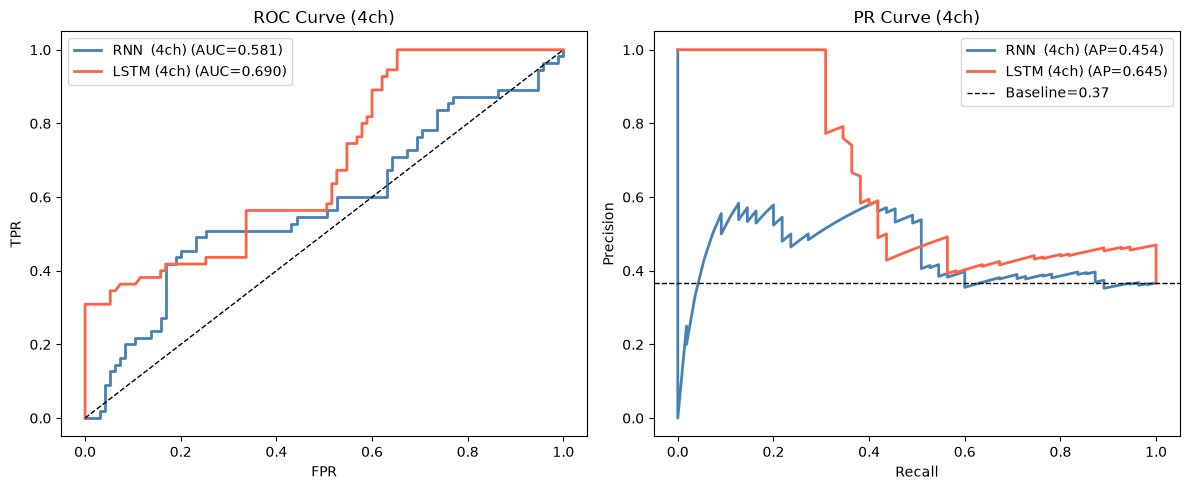

In [31]:
# 비교 요약
df = pd.DataFrame([
    {'Model': k,
     'Weighted F1': round(v['weighted_f1'], 3),
     'Macro F1':    round(v['macro_f1'],    3),
     'ROC-AUC':     round(v['roc_auc'],     3),
     'PR-AUC':      round(v['pr_auc'],      3)}
    for k, v in results.items()
])
print('=== 4채널 EarlyStopping(20) — RNN vs LSTM ===')
print(df.to_string(index=False))

from sklearn.metrics import roc_curve, precision_recall_curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'tomato']
for (name, (yt, yp)), c in zip(roc_data.items(), colors):
    fpr, tpr, _ = roc_curve(yt, yp)
    axes[0].plot(fpr, tpr, lw=2, color=c,
                 label=f'{name} (AUC={roc_auc_score(yt,yp):.3f})')
    pre, rec, _ = precision_recall_curve(yt, yp)
    axes[1].plot(rec, pre, lw=2, color=c,
                 label=f'{name} (AP={average_precision_score(yt,yp):.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve (4ch)'); axes[0].legend()
baseline = y['test'].mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline={baseline:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve (4ch)'); axes[1].legend()
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'roc_pr_4ch.png'), dpi=150)
plt.show()